# Notebook Classification

In aceasta parte a temei, partea de clasificare va fi facuta pe un dataset cu meciuri de fotbal din Anglia. Contine mai multe meciuri, din mai multi ani, inclusiv anii 90'. Scopul e sa facem o clasificare, sa stim tipul de rezultat final dintre 2 echipe din Premier League.

Link-ul de unde se poate gasi acest dataset este : https://www.kaggle.com/datasets/panaaaaa/english-premier-league-and-championship-full-dataset/data?select=England+CSV.csv

- Contine mai multe date, cum ar fi : data, sezon, cartonare rosii, galbene, fault-uri, cornere, etc. . Totusi, pe unele dintre ele, cum ar fi nr de cartonase, nu avem cum sa le cunoastem de dinainte.
- O metoda de optimizare, este de ex. sa luam media faulturilor sau cartonaselor rosii. De exemplu, daca media cartonaselor rosii din ultimele 5 meciuri e mare atunci exista o tendinta sa piarda acel meci, deoarece exista o probabilitate mare sa ia echipa respectiva un cartonas rosu.
- Coloana pe care dorim sa o prezicem este : ***FT Result***

Astfel, in urma acestui notebook, vom afla top 5 modele de ML care prezic cel mai bun rezultat.


In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
%load_ext autoreload
%autoreload 2

df = pd.read_csv('../Datasets/England CSV.csv')
print(f'Shape: {df.shape}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Shape: (12153, 25)


#### Coloanele:

In [126]:
df.columns

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTH Goals', 'FTA Goals',
       'FT Result', 'HTH Goals', 'HTA Goals', 'HT Result', 'Referee',
       'H Shots', 'A Shots', 'H SOT', 'A SOT', 'H Fouls', 'A Fouls',
       'H Corners', 'A Corners', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
       'Display_Order', 'League'],
      dtype='str')

#### Tipurile de date pentru fiecare coloana:
- putem observa ca unele tipuri de date au si null, deoarece nu sunt 12153, ci mai putine.

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12153 entries, 0 to 12152
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           12153 non-null  str    
 1   Season         12153 non-null  str    
 2   HomeTeam       12153 non-null  str    
 3   AwayTeam       12153 non-null  str    
 4   FTH Goals      12153 non-null  int64  
 5   FTA Goals      12153 non-null  int64  
 6   FT Result      12153 non-null  str    
 7   HTH Goals      11229 non-null  float64
 8   HTA Goals      11229 non-null  float64
 9   HT Result      11229 non-null  str    
 10  Referee        9329 non-null   str    
 11  H Shots        9329 non-null   float64
 12  A Shots        9329 non-null   float64
 13  H SOT          9329 non-null   float64
 14  A SOT          9329 non-null   float64
 15  H Fouls        9329 non-null   float64
 16  A Fouls        9329 non-null   float64
 17  H Corners      9329 non-null   float64
 18  A Corners      93

In [128]:
df.head()

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,A,0.0,1.0,A,...,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,0.0,1.0,A,...,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,0.0,0.0,D,...,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,0.0,0.0,D,...,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,1.0,0.0,H,...,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League


### Analiza calitativa / curatarea datelor:
- se obs ca datele sunt null unde sunt meciuri de mult timp , ex din 96', cand nu se puteau colecta datele.
- in plus, pentru predictia actuala nu conteaza, nu are vreo importanta, deci vom elimina randurile acelea

In [129]:
df.isnull().sum()

Date                0
Season              0
HomeTeam            0
AwayTeam            0
FTH Goals           0
FTA Goals           0
FT Result           0
HTH Goals         924
HTA Goals         924
HT Result         924
Referee          2824
H Shots          2824
A Shots          2824
H SOT            2824
A SOT            2824
H Fouls          2824
A Fouls          2824
H Corners        2824
A Corners        2824
H Yellow         2824
A Yellow         2824
H Red            2824
A Red            2824
Display_Order       0
League              0
dtype: int64

In [130]:
df.dropna(inplace=True)
df.shape

(9329, 25)

#### Acum nu mai exista randuri cu valori null si ar fi toate date relevante

In [131]:
df.isnull().sum()

Date             0
Season           0
HomeTeam         0
AwayTeam         0
FTH Goals        0
FTA Goals        0
FT Result        0
HTH Goals        0
HTA Goals        0
HT Result        0
Referee          0
H Shots          0
A Shots          0
H SOT            0
A SOT            0
H Fouls          0
A Fouls          0
H Corners        0
A Corners        0
H Yellow         0
A Yellow         0
H Red            0
A Red            0
Display_Order    0
League           0
dtype: int64

### Acum vom renunta la coloanele care nu sunt folositoare, de exemplu: arbitrul, liga, display order , iar data o vom sterge la final.

In [132]:
df = df.drop(['Referee','League','Display_Order'],axis=1)
df.shape

(9329, 22)

# Analiza exploratorie

- dorim sa vedem cum sunt corelate datele, legaturile dintre coloane
- mai jos se vede ca echipa de acaca are o tendinta mai buna pe orice statistica, mai putin la fault uri
- deviatia standard de ajuta la goluri, deoarece datele nu sunt asa imprastiate

In [133]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FTH Goals,9329.0,1.536178,1.305748,0.0,1.0,1.0,2.0,9.0
FTA Goals,9329.0,1.179333,1.157003,0.0,0.0,1.0,2.0,9.0
HTH Goals,9329.0,0.687641,0.835261,0.0,0.0,0.0,1.0,5.0
HTA Goals,9329.0,0.518491,0.734551,0.0,0.0,0.0,1.0,5.0
H Shots,9329.0,13.618716,5.349420,0.0,10.0,13.0,17.0,43.0
A Shots,9329.0,10.784543,4.678710,0.0,7.0,10.0,14.0,31.0
H SOT,9329.0,6.007503,3.275177,0.0,4.0,6.0,8.0,24.0
A SOT,9329.0,4.704684,2.757288,0.0,3.0,4.0,6.0,20.0
H Fouls,9329.0,11.303462,3.752442,0.0,9.0,11.0,14.0,33.0
A Fouls,9329.0,11.781113,3.931377,1.0,9.0,12.0,14.0,29.0


Asimetria este doar pozitiva pentru ca nu exista ca nr de goluri sa fie negative.

In [134]:
df.skew(numeric_only=True)

FTH Goals    0.975128
FTA Goals    1.076766
HTH Goals    1.217881
HTA Goals    1.481468
H Shots      0.642805
A Shots      0.655182
H SOT        0.823543
A SOT        0.873413
H Fouls      0.437434
A Fouls      0.406391
H Corners    0.615626
A Corners    0.737246
H Yellow     0.769340
A Yellow     0.623094
H Red        4.147739
A Red        3.337277
dtype: float64

Majoritatea echipelor de acasa castiga.Asta influenteaza mult, unde se joaca.

In [135]:
df["FT Result"].value_counts()

FT Result
H    4278
A    2738
D    2313
Name: count, dtype: int64

La pauza exista mai multe partide la un rezultat de egalitate.

In [136]:
df["HT Result"].value_counts()

HT Result
D    3818
H    3268
A    2243
Name: count, dtype: int64

Mai jos se pot observa urmatoarele :
- foarte rar conduce echipa de acasa la pauza si ea tot pierde. Adica daca away conduce la pauza, in maj cazurilor, mai bine de jumate, castiga si meciul.
- daca echipa de acasa castiga la pauza , are cele mai mari sanse sa castige meciul.
- cele mai multe sunt egaluri la pauza.
- cele mai multe victorii la final sunt la gazde.

In [137]:
pd.crosstab(df['HT Result'], df['FT Result'], margins=True)

FT Result,A,D,H,All
HT Result,,,,
A,1565,443,235,2243
D,994,1405,1419,3818
H,179,465,2624,3268
All,2738,2313,4278,9329


Grafic pentru rezultatul final, la fel ca la value_counts.

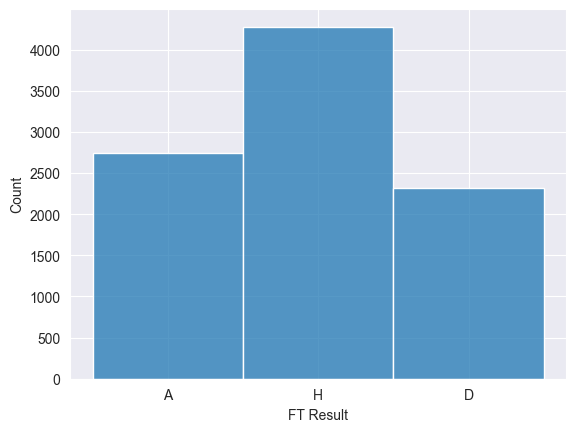

In [138]:
sns.histplot(data = df, x="FT Result")
plt.show()

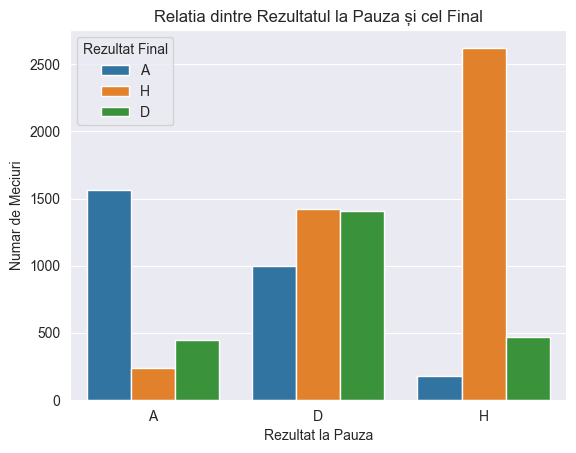

In [139]:
sns.countplot(data=df, x='HT Result', hue='FT Result')

plt.title('Relatia dintre Rezultatul la Pauza și cel Final')
plt.xlabel('Rezultat la Pauza')
plt.ylabel('Numar de Meciuri')
plt.legend(title='Rezultat Final')
plt.show()

Exista relatii intre :
- goluri si suturi
- suturi si cornere
- nr de suturi la pauza si final

<Axes: >

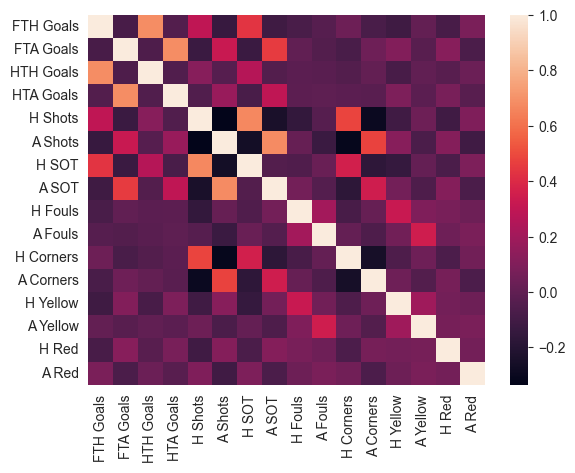

In [140]:
sns.heatmap(df.corr(numeric_only=True))

### Encodare :
- cu datele actuale nu ne putem da seama neaparat de relatii foarte specifice si vom encoda echipele, H,A,D

In [141]:
res_grid = {'H' : 0, 'D':1, 'A':2}
df['FT Result'] = df['FT Result'].str.strip()
df['HT Result'] = df['HT Result'].str.strip()
df['FT Result'] = df['FT Result'].map(res_grid)
df['HT Result'] = df['HT Result'].map(res_grid)


In [142]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,Man United,Southampton,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,Arsenal,Tottenham,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,Brentford,Man City,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


- pentru a codifica corect echipele si pt a avea acelasi cod si la home si la away facem un dictionar prin reuniune si apoi codificam tot

In [143]:
common_set = set(df['HomeTeam']).union(set(df['AwayTeam']))
print(common_set)

{'West Brom', 'Derby', 'Norwich', 'Brighton & Hove Albion', 'Leicester', 'Portsmouth', 'Charlton', "Nott'm Forest", 'Watford', 'Reading', 'West Ham', 'Leeds', 'Fulham', 'Bournemouth', 'Brentford', 'Hull', 'Sunderland', 'Middlesbrough', 'QPR', 'Blackpool', 'Burnley', 'Brighton', 'Liverpool', 'Wolves', 'Stoke', 'Ipswich', 'Arsenal', 'Aston Villa', 'Cardiff', 'Newcastle', 'Southampton', 'Luton', 'Bolton', 'Bradford', 'Tottenham', 'Man United', 'Coventry', 'Ipswich Town', 'Birmingham', 'Chelsea', 'Sheffield United', 'Crystal Palace', 'Man City', 'Everton', 'Wigan', 'Swansea', 'Huddersfield', 'Blackburn'}


In [144]:
sorted_teams = sorted(list(common_set))
team_grid = {team:i for i, team in enumerate(sorted_teams)}
print(team_grid)

{'Arsenal': 0, 'Aston Villa': 1, 'Birmingham': 2, 'Blackburn': 3, 'Blackpool': 4, 'Bolton': 5, 'Bournemouth': 6, 'Bradford': 7, 'Brentford': 8, 'Brighton': 9, 'Brighton & Hove Albion': 10, 'Burnley': 11, 'Cardiff': 12, 'Charlton': 13, 'Chelsea': 14, 'Coventry': 15, 'Crystal Palace': 16, 'Derby': 17, 'Everton': 18, 'Fulham': 19, 'Huddersfield': 20, 'Hull': 21, 'Ipswich': 22, 'Ipswich Town': 23, 'Leeds': 24, 'Leicester': 25, 'Liverpool': 26, 'Luton': 27, 'Man City': 28, 'Man United': 29, 'Middlesbrough': 30, 'Newcastle': 31, 'Norwich': 32, "Nott'm Forest": 33, 'Portsmouth': 34, 'QPR': 35, 'Reading': 36, 'Sheffield United': 37, 'Southampton': 38, 'Stoke': 39, 'Sunderland': 40, 'Swansea': 41, 'Tottenham': 42, 'Watford': 43, 'West Brom': 44, 'West Ham': 45, 'Wigan': 46, 'Wolves': 47}


In [145]:
df["HomeTeam"] = df['HomeTeam'].astype(str).str.strip()
df["AwayTeam"] = df['AwayTeam'].astype(str).str.strip()
df['HomeTeam'] = df['HomeTeam'].map(team_grid)
df['AwayTeam'] = df['AwayTeam'].map(team_grid)

In [146]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,23,10,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,29,38,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,18,1,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,25,16,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,31,47,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,0,42,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,8,28,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


### Dupa codificare :
Dupa aceasta etapa urmeaza etapa de a adauga date noi , din urma carora sa rezulte relatii intre coloane.Vom incerca sa adaugam:
- rezultatul ultimelor 5 partite a echipei, inainte de meciul respectiv(0p = Lose, 1p = Draw, 3p = Win) pentru fiecare echipa
- nr de cartonase rosii in ultimele 5 meciuri pentru fiecare echipa
- H2H: ultimele 5 rezultate intre cele 2 echipe (0 = echipa din away a castigat toate meciurile directe, 1= echipa de acasa a catigat 1/5 meciuri directe si tot asa.)
- nr de goluri marcate de fiecare echipa in ultimele 5 meciuri
- nr de goluri primite de fiecare echipa in ultimele 5 meciuri

Inainte de stergerea coloanelor trebuie sa adaugam noile statistici din datele brute:

In [147]:
from Classes.FootballFeature import FootballFeature
from Classes.Utils import create_columns

features = FootballFeature(df)
df = create_columns(df,features,n=5)



### Stergem coloanele de date brute:

In [148]:
df = df.drop(columns=['FTH Goals', 'FTA Goals', 'HTH Goals', 'HTA Goals','HT Result',
              'HTH Goals', 'HTA Goals', 'HT Result',
              'H Shots', 'A Shots','H SOT', 'A SOT',
              'H Corners', 'A Corners','H Fouls', 'A Fouls', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
              'Date','Season'])

Cum arata noul tabel:

In [149]:
df.head(5)

,HomeTeam,AwayTeam,FT Result,H_Scored_Avg,A_Scored_Avg,H_Conceded_Avg,A_Conceded_Avg,H_Points_Avg,A_Points_Avg,H_Red_Avg,A_Red_Avg,H2H_Score,Diff_Form,Diff_Scored,Diff_Conceded
1,29,38,0,0.8,0.2,2.0,2.6,0.8,0.2,0.2,0.0,2,0.6,0.6,-0.6
2,18,1,2,0.2,1.4,0.8,1.8,0.6,1.4,0.0,0.2,0,-0.8,-1.2,-1.0
3,25,16,2,0.4,1.4,2.8,1.6,0.0,1.6,0.0,0.0,1,-1.6,-1.0,1.2
4,31,47,0,3.0,1.6,0.2,1.4,3.0,1.4,0.0,0.2,3,1.6,1.4,-1.2
5,0,42,0,2.0,2.2,0.6,2.2,2.2,0.8,0.0,0.2,4,1.4,-0.2,-1.6


Acum avem 15 coloane, cu datele din trecut si putem prezice pe baza acestor statistici.

In [150]:
df.shape

(9049, 15)

# ANALIZA EXPLORATORIE A DATELOR: ETAPA 2
In aceasta etapa urmarim din nou analiza exploratorie a datelor, dar pe noile statistici.
- dorim sa vedem corelari intre diferite atribute pentru a putea creea un model de ML compact.
- este de asteptat ca rezultatele sa nu fie foarte bune, speram ca nici foarte rele, deoarece fotbalul este mai imprevizibil si depinde de mult mai multi factori externi. Totusi, vom incerca pe baza datelor gasite, statistici cat de cat valide.
- reamintim ca clasificarea, rezultatul pe care dorim sa il prezicem, este rezultatul final, adica coloana de *** FT Result***.(ea va fi vectorul y, iar restul matricea X).

<Axes: >

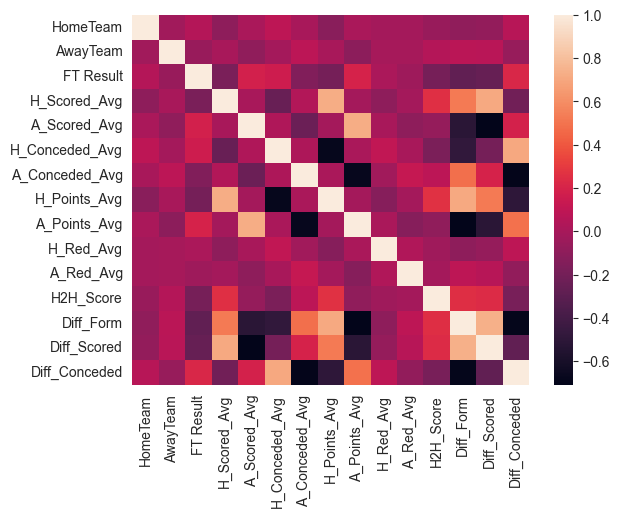

In [151]:
sns.heatmap(df.corr(numeric_only=True))


Deocamdata se observa rezultate intre :
- goluri si puncte
- forma(diferenta de forma) si puncte
- H2H depinde putin de golurile inscrise de echipele de acasa

**Nota** : diferenta de forma este media de puncte(forma) echipei de acasa - cea din deplasare.

Mai departe vom face grafice cu noile rezultate calculate sa vedem cum este distributia lor in functie de rezultatul final.

### Grafice cu media golurilor in functie de rezultatul final.

Ce se poate observa din informatiile datelor de pana acum:
- FT Result e aproape de 1(Draw) si de 0(castiga echipa gazda), asta si pentru ca media golurilor inscrise si primite sunt asemanatoare, asemenea si pentru puncte.
Deci multe meciuri, o mare majoritate, au rezultatul final in favoarea egalului sau a echipei de acasa.
- media cartonaselor rosii nu ne ajuta ca e aproape 0
- media golurilor inscrise acasa

In [159]:
df.describe()

,HomeTeam,AwayTeam,FT Result,H_Scored_Avg,A_Scored_Avg,H_Conceded_Avg,A_Conceded_Avg,H_Points_Avg,A_Points_Avg,H_Red_Avg,A_Red_Avg,H2H_Score,Diff_Form,Diff_Scored,Diff_Conceded
count,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000
mean,24.653000,24.702509,0.837330,1.357807,1.372041,1.367488,1.344966,1.369654,1.396044,0.074329,0.074019,1.243894,-0.026390,-0.014234,0.022522
std,14.431017,14.409613,0.852296,0.652474,0.645210,0.617473,0.612978,0.684296,0.679377,0.122874,0.122665,1.387257,0.968825,0.915705,0.859699
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-3.800000,-4.000000
25%,14.000000,14.000000,0.000000,0.800000,1.000000,1.000000,1.000000,0.800000,0.800000,0.000000,0.000000,0.000000,-0.600000,-0.600000,-0.600000
50%,26.000000,26.000000,1.000000,1.200000,1.200000,1.400000,1.200000,1.400000,1.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,38.000000,38.000000,2.000000,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,0.200000,0.200000,2.000000,0.600000,0.600000,0.600000
max,47.000000,47.000000,2.000000,5.800000,4.800000,4.200000,4.600000,3.000000,3.000000,0.800000,0.800000,5.000000,3.000000,5.200000,3.400000


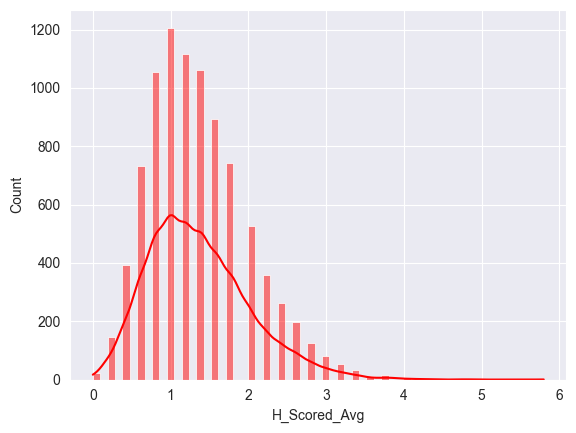

In [163]:
sns.histplot(data=df, x='H_Scored_Avg',kde=True, color='red')
plt.show()

In graficul de mai jos putem observa ca media este aproape asemanatoare la inscrierea golurile de ambele tipuri de echipe. Totusi, echipa din deplasare ar niste anomalii mult mai apropiate de zona acceptabila, fata de echipele de acasa.

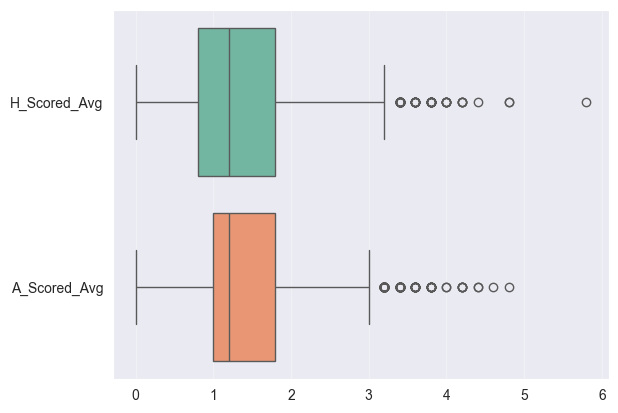

In [168]:
sns.boxplot(data=df[['H_Scored_Avg', 'A_Scored_Avg']], orient='h', palette='Set2')
plt.grid(axis='x', alpha=0.3)
plt.show()

In graficul de mai jos ne sunt explicate urmatoarele:
- majoritatea echipelor de acasa  reusesc sa aiba 0,1 sau maxim 2 victorii in ultimele 5 meciuri cu cealalta echipa, media fiind la 1.
- este prezentata si diferenta de forma. Exista echipe care au avut o forma exceptionala sau mai putin buna, in afara intervalului 'normal', cu 3 victorii sau infrangeri.Media este la 0, deoarece cele mai multe echipe au forma doar cu o victorie in plus sau in minus fata de alta, deci rezulta ca meciurile sunt destul de echilibrate.

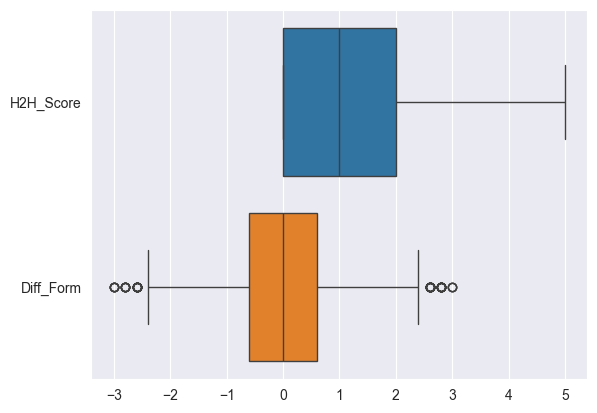

In [172]:
sns.boxplot(data=df[['H2H_Score','Diff_Form']], orient='h')
plt.show()

Mai departe, dorim sa vedem distributia valorilor in cazul unor atribute, cum ar fi:
- diferenta de goluri primite si date, forma
- media punctelor pentru fiecare echipa (acestea descriu si H2H)

<Axes: ylabel='Density'>

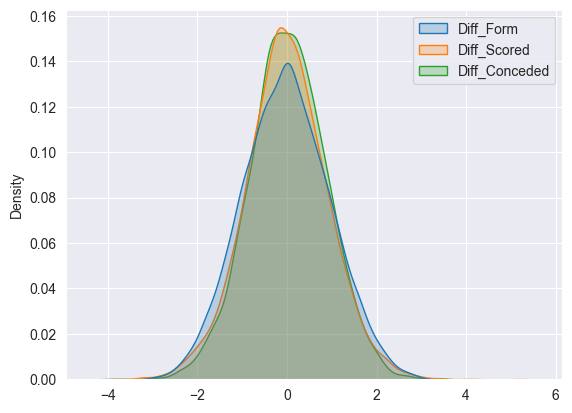

In [174]:
sns.kdeplot(data=df[['Diff_Form', 'Diff_Scored', 'Diff_Conceded']],fill=True)

- in graficul de mai sus, toate cele 3 sunt destul de asemanatoare, diferenta de forma are deviatia standart putin mai mare fata de celelalte.

### In urmatoarea parte dorim sa vede numeric, cat de strans sunt legate datele, prin coeficienti:

Cea mai puternica legatura cu rezultatul o are diferenta golurilor primite
- mai este si away avarage points

In [175]:
df.corr(numeric_only=True)

,HomeTeam,AwayTeam,FT Result,H_Scored_Avg,A_Scored_Avg,H_Conceded_Avg,A_Conceded_Avg,H_Points_Avg,A_Points_Avg,H_Red_Avg,A_Red_Avg,H2H_Score,Diff_Form,Diff_Scored,Diff_Conceded
HomeTeam,1.000000,-0.027256,0.052012,-0.097277,0.011889,0.090225,0.004533,-0.117078,0.011528,-0.007418,-0.010575,-0.059183,-0.090777,-0.077691,0.061571
AwayTeam,-0.027256,1.000000,-0.060717,0.002032,-0.093188,-0.007636,0.081020,0.003875,-0.104959,-0.006936,-0.002135,0.051267,0.076338,0.067108,-0.063253
FT Result,0.052012,-0.060717,1.000000,-0.180282,0.184872,0.154387,-0.148552,-0.200657,0.195374,0.018587,-0.035989,-0.193307,-0.278731,-0.258719,0.216807
H_Scored_Avg,-0.097277,0.002032,-0.180282,1.000000,0.004160,-0.248257,0.041668,0.725357,-0.011945,-0.095922,-0.013670,0.257091,0.520707,0.709606,-0.208019
A_Scored_Avg,0.011889,-0.093188,0.184872,0.004160,1.000000,0.027446,-0.235017,-0.012606,0.722370,0.002070,-0.099641,-0.072962,-0.515457,-0.701641,0.187283
H_Conceded_Avg,0.090225,-0.007636,0.154387,-0.248257,0.027446,1.000000,0.023690,-0.682549,0.006048,0.101077,0.001016,-0.169028,-0.486336,-0.196231,0.701352
A_Conceded_Avg,0.004533,0.081020,-0.148552,0.041668,-0.235017,0.023690,1.000000,0.007696,-0.676482,-0.023044,0.119857,0.085502,0.479811,0.195284,-0.696000
H_Points_Avg,-0.117078,0.003875,-0.200657,0.725357,-0.012606,-0.682549,0.007696,1.000000,-0.009473,-0.129643,-0.009157,0.263397,0.712958,0.525725,-0.495724
A_Points_Avg,0.011528,-0.104959,0.195374,-0.011945,0.722370,0.006048,-0.676482,-0.009473,1.000000,0.011255,-0.133829,-0.090234,-0.707929,-0.517497,0.486686
H_Red_Avg,-0.007418,-0.006936,0.018587,-0.095922,0.002070,0.101077,-0.023044,-0.129643,0.011255,1.000000,0.033545,-0.033874,-0.099461,-0.069807,0.089029


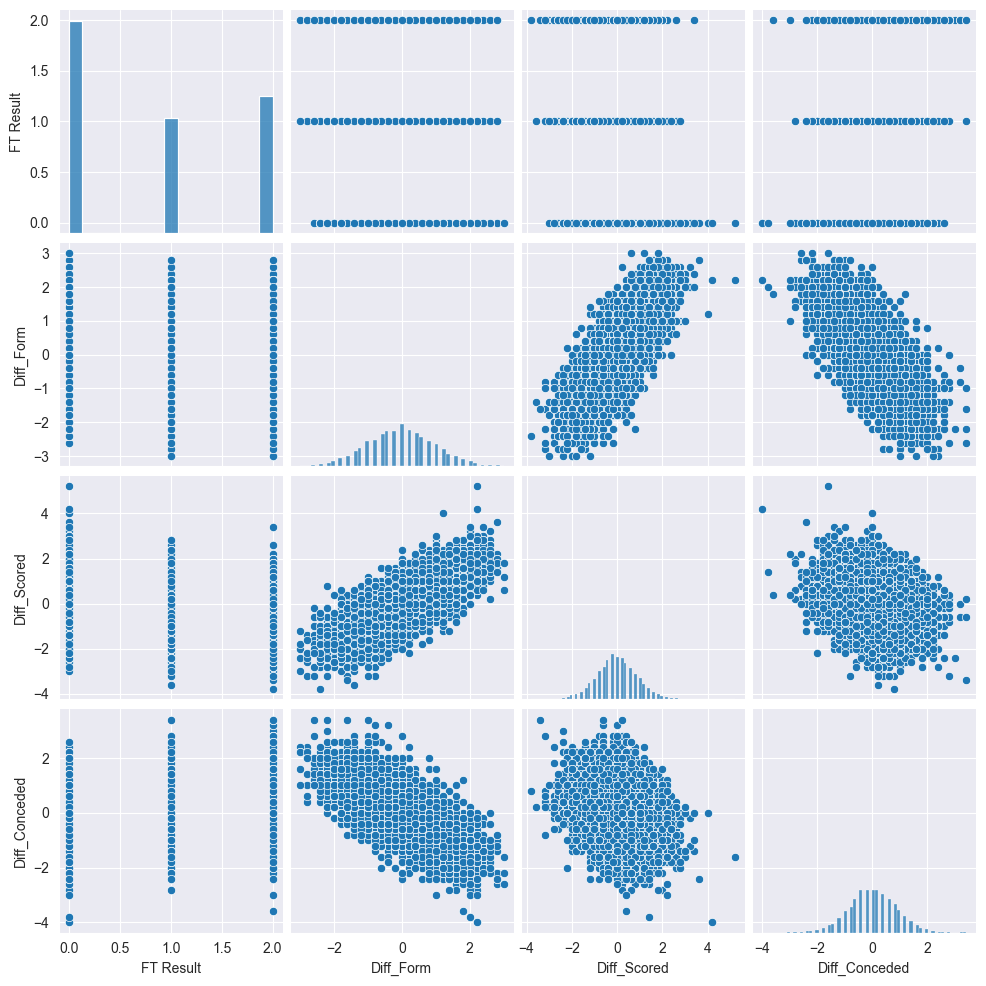

In [176]:
sns.pairplot(df[['FT Result', 'Diff_Form', 'Diff_Scored', 'Diff_Conceded']])

In graficele de mai sus, se observa o relatie de linearitate intre cele mai influente statistici asupra rezultatului final.
Aceasta proprietate apare intre :
- diferenta de forma cu diferenta de goluri inscrise si primite. Forma creste, diferenta de goluri primite scade (pentru gazda), daca forma creste, nr. de goluri inscrise creste.
DECI REZULTA URMATOARELE : forma direct proportional cu goluri inscrise si invers proportional cu goluri primite.

# Etapa de analiza a algoritmilor de clasificare
Un urmatoarea parte a notebook-ului se vor rula pe rand fiecare algoritm de clasificare din cerita, iar pe parcurs, la fiecare se va face analiza pe precizie,acuratete, recall, f1_score, dar si se va trasa si explica curba de invatare
In plus, se vor analiza rezultatele cu biblioteca ***SHAP*** si se vor ajusta hiperparametrii pentru a ajunge la rezultate mai bune, insa vor avea grija la overfitting.

## 1. Naïve Bayes
Scurta descriere: Se foloseste formula lui Bayes intr-o retea de tip bayes, unde exista mai multe noduri care sunt dependente intre ele.
Una dintre cele mai bune solutii este dupa formula lui Gauss, unde se urmaresste acea distributie sub forma unui clopot, avand formula :
$$P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

- iar formula lui Bayes este : $$P(H | E) = \frac{P(E | H) \cdot P(H)}{P(E)}$$

**Nota**: In cazul nostru, vom folosi modelul gaussian, deoarece lucram pe date de tip numere.
- mai exista si multinomial care este pentru cuvinte(frecventa lor) sau Bernoulli care lucreaza doar cu valori binare.

*Hiperparamterii*:
- var_smoothing : pt a netezi curba, pentru stabilitatea calculelor - valoarea default = 1e-9.
- priors : influenteaza probabilitatile ( nu il folosim )

In [218]:
from sklearn.preprocessing import StandardScaler

y = df['FT Result']
X = df.drop('FT Result',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
              precision    recall  f1-score   support

           0       0.55      0.74      0.63      1006
           1       0.44      0.01      0.01       558
           2       0.44      0.58      0.50       699

    accuracy                           0.51      2263
   macro avg       0.48      0.44      0.38      2263
weighted avg       0.49      0.51      0.44      2263



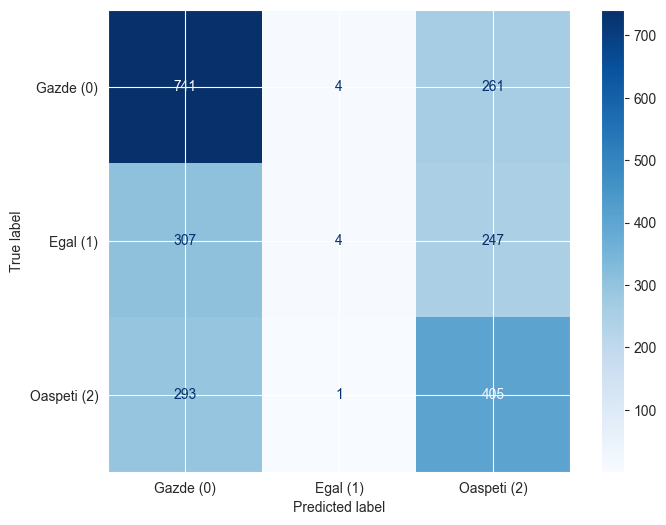

Total Accuracy: 0.51
Total precision : 0.48
Total Recall : 0.44
Total f1-score : 0.38
Total roc_auc : 0.63


In [224]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix,classification_report, ConfusionMatrixDisplay

naive_ml = GaussianNB()
params_naive_grid = {
    'var_smoothing' : np.logspace(0, -9, num=100)
}

grid_search_cv = GridSearchCV(
    estimator=naive_ml,
    param_grid=params_naive_grid,
    cv = 5,
    n_jobs=-1,
    verbose=1
)

grid_search_cv.fit(X_train_scaled, y_train)
y_pred_Bayes =grid_search_cv.predict(X_test_scaled)
y_probs_Bayes = grid_search_cv.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_Bayes))
acc_bayes = accuracy_score(y_test, y_pred_Bayes)
prec_bayes = precision_score(y_test, y_pred_Bayes, average='macro')
rec_bayes = recall_score(y_test, y_pred_Bayes, average='macro')
f1_bayes = f1_score(y_test, y_pred_Bayes, average='macro')
roc_auc_bayes = roc_auc_score(y_test, y_probs_Bayes, multi_class='ovr', average='macro')

cm_bayes = confusion_matrix(y_test, y_pred_Bayes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bayes, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()
print(f"Total Accuracy: {acc_bayes:.2f}")
print(f"Total precision : {prec_bayes:.2f}")
print(f"Total Recall : {rec_bayes:.2f}")
print(f"Total f1-score : {f1_bayes:.2f}")
print(f"Total roc_auc : {roc_auc_bayes:.2f}")


#### Ce putem observa in datele prezise de Naive Bayes?
- Acuratetea este de 51%, adica avem sansa de 51% sa alegem rezultatul corect ( fata de 33% in cazul in care nu cunoastem).
- Precizia, recall si f1-score au rezultate foarte bune in cazul in care este castigatoare echipa gazda, dar si cea din deplasare are rezultate bunicele.
- Din acel recall de 0.01 de la rezultatul de egalitate rezulta faptul ca modelul nostru aproape niciodata nu alege rezultatul final ca fiind egalitate. Precizia acceptabila apare din cauza faptului ca nu multe meciuri se termina la egalitate.
- rezultatele finale de tip macro reprezinta media aritmetica pe toate cele 3 cazuri
- din matricea de confuzie putem observa ca cele mai multe prezice victoriile gazdelor, apoi a oaspetilor
- masurarea auc_roc, fiind folosita la clasificare binara, este folosit parametrul *ovr*(one versus rest), care face tot o binarizare, ce nu ne intereseaza pune in aceeasi clasa.
- f1-score are valoarea cea mai mica datorita faptului ca modelul de ML nu vede egalurile.


## 2. Logistic Regression
Acest algoritm de ML prezice probabilitatea pentru un tip, in cazul nostru probabilitatea daca meciul se va termina H, D, A. Din punct de vedere matematic, incearca sa separa planul in 2 parti, dupa functia sigmoid:
$$s(x) = \frac{1}{1 + e^{-x}}$$
- aceasta functie limiteaza valoriile intre 0 si 1, deoarece limita din infinit tinde la 1 aceasta functie iar din -infinit la 0.
- in functia de mai sus, x reprezinta combinatia liniara dintre toate variabilele si ponderile pe care le invata pe parcurs.
- Daca s(x) > 0.5 atunci este foarte probabil ca acest eveniment sa se intample, altfel nu.

Hiperparametrii:
- exista param multi_class, deoarece clasificarea noastra se incadreaza in acest caz, avem 3 posibilie rezultate, deci mai multe clase. Acum se pune automat param multi_class.

In [226]:

logistic_grid ={
        'C': np.logspace(-5, 2, 20),
        'solver': ['saga'],
        'class_weight': ['balanced'],
        'max_iter': [2000]
    }

Fitting 5 folds for each of 20 candidates, totalling 100 fits
              precision    recall  f1-score   support

           0       0.58      0.64      0.61      1006
           1       0.24      0.05      0.08       558
           2       0.43      0.63      0.51       699

    accuracy                           0.49      2263
   macro avg       0.41      0.44      0.40      2263
weighted avg       0.45      0.49      0.45      2263



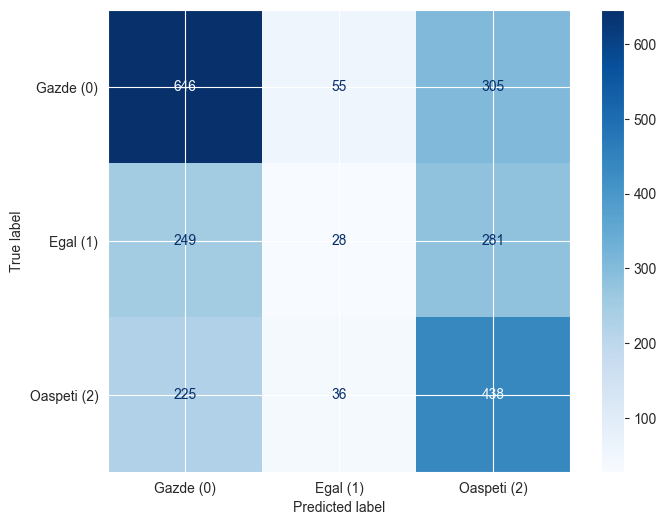

Total Accuracy: 0.49
Total precision : 0.41
Total Recall : 0.44
Total f1-score : 0.40
Total auc_roc : 0.61


In [227]:
from sklearn.linear_model import LogisticRegression

log_reg_ml = LogisticRegression()

grid_search_log = GridSearchCV(
    estimator=log_reg_ml,
    param_grid=logistic_grid,
    n_jobs=-1,
    verbose=1,
    cv=5
)

grid_search_log.fit(X_train_scaled,y_train)
y_pred_logistic = grid_search_log.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_logistic))
acc_logistic = accuracy_score(y_test,y_pred_logistic)
prec_logistic = precision_score(y_test,y_pred_logistic, average='macro')
f1_logistic = f1_score(y_test,y_pred_logistic, average='macro')
rec_logistic = recall_score(y_test, y_pred_logistic, average='macro')
y_probs_logistic = grid_search_log.predict_proba(X_test_scaled)
auc_roc_logistic = roc_auc_score(y_test,y_probs_logistic, multi_class='ovr', average='macro')

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_logistic:.2f}")
print(f"Total precision : {prec_logistic:.2f}")
print(f"Total Recall : {rec_logistic:.2f}")
print(f"Total f1-score : {f1_logistic:.2f}")
print(f"Total auc_roc : {auc_roc_logistic:.2f}")

#### Ce putem observa in datele prezise de Naive Bayes?
- Rezultatele sunt foarte asemanatoare cu modelul anterior.
- Acuratetea a scazut foarte putin fata de anterior si precizia, dar overall putin mai bun, deoarece creste f1-score.
- Scaderea usoara a acuratetii si a precizie se datoreaza faptului ca modelul de ML incepe sa isi mai asume riscul de egal.

### 3.Decision Tree
